# Hierarchical CBM — Interpretability Walkthrough

**Model:** Hierarchical Concept Bottleneck Model (H-CBM)  
**Backbone:** ViT-B/16 SWAG (384×384) — frozen identity heads, 768-d feature  
**Concept hierarchy:** 13 body parts → 312 fine-grained attributes → 200 species

**Why this notebook is different from a CBM/PCBM-h walkthrough:**
Our model has **no `W_r` residual pathway**. The classifier sees ONLY the 312
concept probabilities `p_f`. This means **every prediction is fully describable**
by the 312 concepts, and we can study the concept layer without worrying that a
black-box residual is silently doing the work.

**The decision pipeline is purely hierarchical:**

```
image  ──► ViT  ──► f (768)
                     │
                     ├──► coarse_head ──► z_c (13) ──► p_c = σ(z_c)
                     │                                    │
                     └──► fine_head([f ; p_c]) ──► z_f (312)
                                                          │
                                          p_f[i] = σ(z_f[i]) · (0.5 + 0.5·p_c[parent(i)])
                                                          │
                                              cls = W·p_f + b   →  argmax
```

**Sections in this notebook (Section 1 is the headline walkthrough):**

| # | What it shows                                       | Interpretability role                  |
|---|-----------------------------------------------------|----------------------------------------|
| 1 | Single-image hierarchical decision walkthrough      | "How was THIS prediction made?"        |
| 2 | Gallery of correct + wrong predictions              | Diversity of explanations              |
| 3 | Full-eval forward-pass cache                        | (data prep for sections 4–9)           |
| 4 | Concept fidelity — oracle accuracy with GT concepts | Upper bound the bottleneck allows      |
| 5 | Test-Time Intervention (TTI) curve                  | Causal control via concepts            |
| 6 | Per-attribute quality (F1, AUC, calibration)        | "Are concepts learned correctly?"      |
| 7 | Classifier weight inspection                        | Direct definition of each species      |
| 8 | Class prototype signatures                          | What concepts each species actually has|
| 9 | Per-part causal necessity (ablation)                | Which body parts the model can't lose  |


## Setup — load checkpoint, build model, prepare helpers

**This cell does:** mount Drive, define the H-CBM class (identical to the
training file), load the trained checkpoint into a fresh (uncompiled) model,
prepare image transforms and class-name lookup. After this, all later cells
build on the loaded `model`, the cached `splits`, and the helper transforms.

**Interpretability output:** a printed sanity check that confirms the
checkpoint loaded, the architecture matches, and the eval split is ready.


In [1]:
# Setup — Drive, checkpoint, model, transforms, helpers
import os, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT    = "/content/drive/MyDrive/XAI-Project/DB/DB1"
PKL_DIR       = f"{DRIVE_ROOT}/pipeline"
CKPT_DIR      = f"{DRIVE_ROOT}/checkpoints"
PIPELINE_FILE = f"{PKL_DIR}/data_pipeline_vit.pkl"
CKPT_PATH     = f"{CKPT_DIR}/best_hcbm_vit_384.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pipeline
with open(PIPELINE_FILE, "rb") as f: pipeline = pickle.load(f)
splits, meta, paths = pipeline["splits"], pipeline["meta"], pipeline["paths"]

# CRITICAL: CUB stores class labels 1-indexed (1..200). Training's BirdDataset
# does `label = labels[idx] - 1` to convert to 0-indexed before feeding the loss,
# so the trained classifier outputs class indices 0..199. Normalize to 0-indexed
# once, here, for every split.
for _s in splits.values():
    _lbl = np.asarray(_s["labels"])
    if _lbl.min() >= 1:
        _s["labels"] = (_lbl - 1).astype(np.int64).tolist()

DATA_ROOT       = paths["dataset_dir"]
NUM_L1, NUM_L2  = meta["NUM_L1"], meta["NUM_L2"]
NUM_CLASSES     = 200
IMG_SIZE        = int(meta.get("IMG_SIZE", 384))
BODY_PART_NAMES = meta["CONCEPT_NAMES"]                    # 13 part names
attr_parent_idx = np.array(meta["attr_parent_idx"])        # (312,) → 0..12 or -1
attr_names      = meta.get("attr_names", [f"attr_{i}" for i in range(NUM_L2)])
EVAL_SPLIT      = "test" if "test" in splits else "val"

# Class names
with open(os.path.join(DATA_ROOT, "classes.txt")) as fc:
    raw = [ln.strip().split(" ", 1)[1] for ln in fc]
class_names = [c.split(".", 1)[1].replace("_", " ") for c in raw]


# H-CBM (ViT-B/16) class — must match the training file exactly,
# INCLUDING the SOFT hierarchical mask  mask = 0.5 + 0.5 · p_c[parent].
class HierarchicalCBM(nn.Module):
    def __init__(self, attr_parent_idx, num_classes=200, num_l1=13, num_l2=312):
        super().__init__()
        self.num_l1, self.num_l2 = num_l1, num_l2
        self.register_buffer("attr_parent_idx",
                             torch.tensor(attr_parent_idx, dtype=torch.long))
        backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1)
        backbone.heads = nn.Identity()
        self.features = backbone
        self.coarse_head = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.2), nn.Linear(256, num_l1))
        self.fine_head = nn.Sequential(
            nn.Linear(768 + num_l1, 512), nn.BatchNorm1d(512),
            nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_l2))
        self.classifier = nn.Linear(num_l2, num_classes)

    def forward(self, x):
        feats = self.features(x)                              # (B, 768)
        z_c = self.coarse_head(feats); p_c = torch.sigmoid(z_c)
        z_f = self.fine_head(torch.cat([feats, p_c], dim=1))
        p_f_raw = torch.sigmoid(z_f)
        # Soft hierarchical mask (matches training):
        # mask ∈ [0.5, 1.0] for child attrs, 1.0 for orphans.
        pidx = self.attr_parent_idx
        has  = pidx >= 0; safe = pidx.clamp(min=0)
        parent_p = p_c[:, safe]
        soft_parent = 0.5 + 0.5 * parent_p
        mask = torch.where(has.unsqueeze(0), soft_parent, torch.ones_like(parent_p))
        p_f = p_f_raw * mask
        return self.classifier(p_f), z_c, p_c, z_f, p_f


# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
api  = ckpt.get("attr_parent_idx", attr_parent_idx)
model = HierarchicalCBM(api, NUM_CLASSES, NUM_L1, NUM_L2).to(device)

# --- Robust state-dict loading -------------------------------------------------
# Training may have wrapped the model with torch.compile (`_orig_mod.` prefix)
# and/or DataParallel (`module.` prefix). Strip both, in any order, and report
# any leftover mismatches LOUDLY — silently skipping weights with strict=False
# is what causes "looks fine on 1 image but ~chance on the full split" bugs.
sd = ckpt["model_state_dict"]
def _strip(state, prefix):
    return {(k[len(prefix):] if k.startswith(prefix) else k): v
            for k, v in state.items()}
for _ in range(3):
    sd = _strip(sd, "_orig_mod.")
    sd = _strip(sd, "module.")

result = model.load_state_dict(sd, strict=False)
print(f"State-dict load:  saved_keys={len(sd)}  "
      f"missing={len(result.missing_keys)}  "
      f"unexpected={len(result.unexpected_keys)}")
if result.missing_keys:
    print("  ⚠ MISSING keys (model has them, checkpoint does not):")
    for k in result.missing_keys[:15]:    print(f"     {k}")
if result.unexpected_keys:
    print("  ⚠ UNEXPECTED keys (checkpoint has them, model does not):")
    for k in result.unexpected_keys[:15]: print(f"     {k}")

# Hard fail if any actual learnable parameter is missing — explanations on top
# of a partially-loaded model are meaningless.
_critical = [k for k in result.missing_keys
             if any(k.startswith(p) for p in
                    ("features.", "coarse_head.", "fine_head.", "classifier."))]
assert not _critical, (
    f"{len(_critical)} critical weights NOT loaded from checkpoint "
    f"(first: {_critical[:3]}). Predictions would be garbage — fix the "
    f"prefix-stripping above before continuing.")

model.eval()
for p in model.parameters(): p.requires_grad_(False)

# Eval transform (matches training-time eval transform)
tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 256 / 224)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def clean(s, n=40):
    return s.replace("has_", "").replace("::", ": ")[:n]

# Cache classifier weights for direct inspection
W = model.classifier.weight.detach().cpu().numpy()   # (200, 312)
b = model.classifier.bias.detach().cpu().numpy()     # (200,)

print(f"Loaded H-CBM-ViT  ep={ckpt.get('epoch','?')}  "
      f"val_acc={ckpt.get('val_acc',0)*100:.2f}%")
print(f"Eval split: {EVAL_SPLIT}  |  "
      f"{NUM_L1} parts  |  {NUM_L2} attrs  |  {NUM_CLASSES} species")
print(f"IMG_SIZE={IMG_SIZE}  device={device}")
print(f"Classifier weights ready: W{W.shape}  b{b.shape}")

# --- Sanity check ---------------------------------------------------------
# Run the loaded model on a small slice of the eval split and confirm the
# top-1 accuracy is in the right ballpark. If the state-dict load was silently
# broken, this number will be near random (~0.5%) and we want to catch that
# BEFORE running Sections 3-9 which depend on the cached predictions.
_eval0 = splits[EVAL_SPLIT]
_n_chk = min(256, len(_eval0["labels"]))
class _SanityDS(Dataset):
    def __len__(self): return _n_chk
    def __getitem__(self, i):
        rel  = _eval0["images"][i]
        full = rel if os.path.isabs(rel) else os.path.join(DATA_ROOT, "images", rel)
        return tf(Image.open(full).convert("RGB")), int(_eval0["labels"][i])
_dl_chk = DataLoader(_SanityDS(), batch_size=32, num_workers=2)
_ok = 0
with torch.no_grad():
    for _xb, _yb in _dl_chk:
        _out = model(_xb.to(device))[0].argmax(1).cpu()
        _ok += (_out == _yb).sum().item()
_sanity_acc = _ok / _n_chk
print(f"Sanity top-1 on first {_n_chk} eval images: {_sanity_acc*100:.2f}%  "
      f"(checkpoint val_acc={ckpt.get('val_acc',0)*100:.2f}%)")
assert _sanity_acc >= 0.30, (
    f"Sanity accuracy {_sanity_acc*100:.2f}% is way below the checkpoint's "
    f"val_acc — the state-dict load is silently broken. Inspect the missing/"
    f"unexpected keys above and fix the prefix stripping.")


Mounted at /content/drive
Downloading: "https://download.pytorch.org/models/vit_b_16_swag-9ac1b537.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_swag-9ac1b537.pth


100%|██████████| 331M/331M [00:01<00:00, 313MB/s]  


State-dict load:  saved_keys=171  missing=0  unexpected=0
Loaded H-CBM-ViT  ep=66  val_acc=86.50%
Eval split: test  |  13 parts  |  312 attrs  |  200 species
IMG_SIZE=384  device=cuda
Classifier weights ready: W(200, 312)  b(200,)
Sanity top-1 on first 256 eval images: 87.89%  (checkpoint val_acc=86.50%)


---

## Section 1 — How did the model decide *these* predictions?  *(the headline walkthrough)*

**This cell does:** picks **three images** from the eval split and walks through
the decision **step by step, side-by-side**, using the exact formulas the model
uses internally. For each of the three images we will see, in the same order:

1. The image.
2. Compute `f = ViT(image)` — a 768-d feature vector.
3. Compute `z_c = coarse_head(f)` and `p_c = σ(z_c)` — the **13 body-part probabilities**.
4. Compute `z_f = fine_head([f ; p_c])` and apply the **hierarchical mask**:  
   `p_f[i] = σ(z_f[i]) · (0.5 + 0.5·p_c[parent(i)])` — the **312 attribute probabilities**.
5. Compute the class score for every species: `logit[k] = Σᵢ W[k,i]·p_f[i] + b[k]`.
6. Predict `argmax_k logit[k]`.
7. Decompose the winning class score into its top contributing concepts:  
   `contribution[i] = W[predicted, i] · p_f[i]`.

**Interpretability output:** a **3-column figure** (one column per image), each
column with 4 rows: image / 13 part-probabilities / attributes inside the most
active part (showing the mask multiplication) / top contributors to the
predicted class. Below the figure we print the step-by-step formula trace with
**actual numerical values** for each of the three images. Because there is no
residual pathway, this trace is the **complete causal story** of every
prediction — nothing is hidden.

> Change `IDXS = [0, 1, 2]` to inspect different samples.


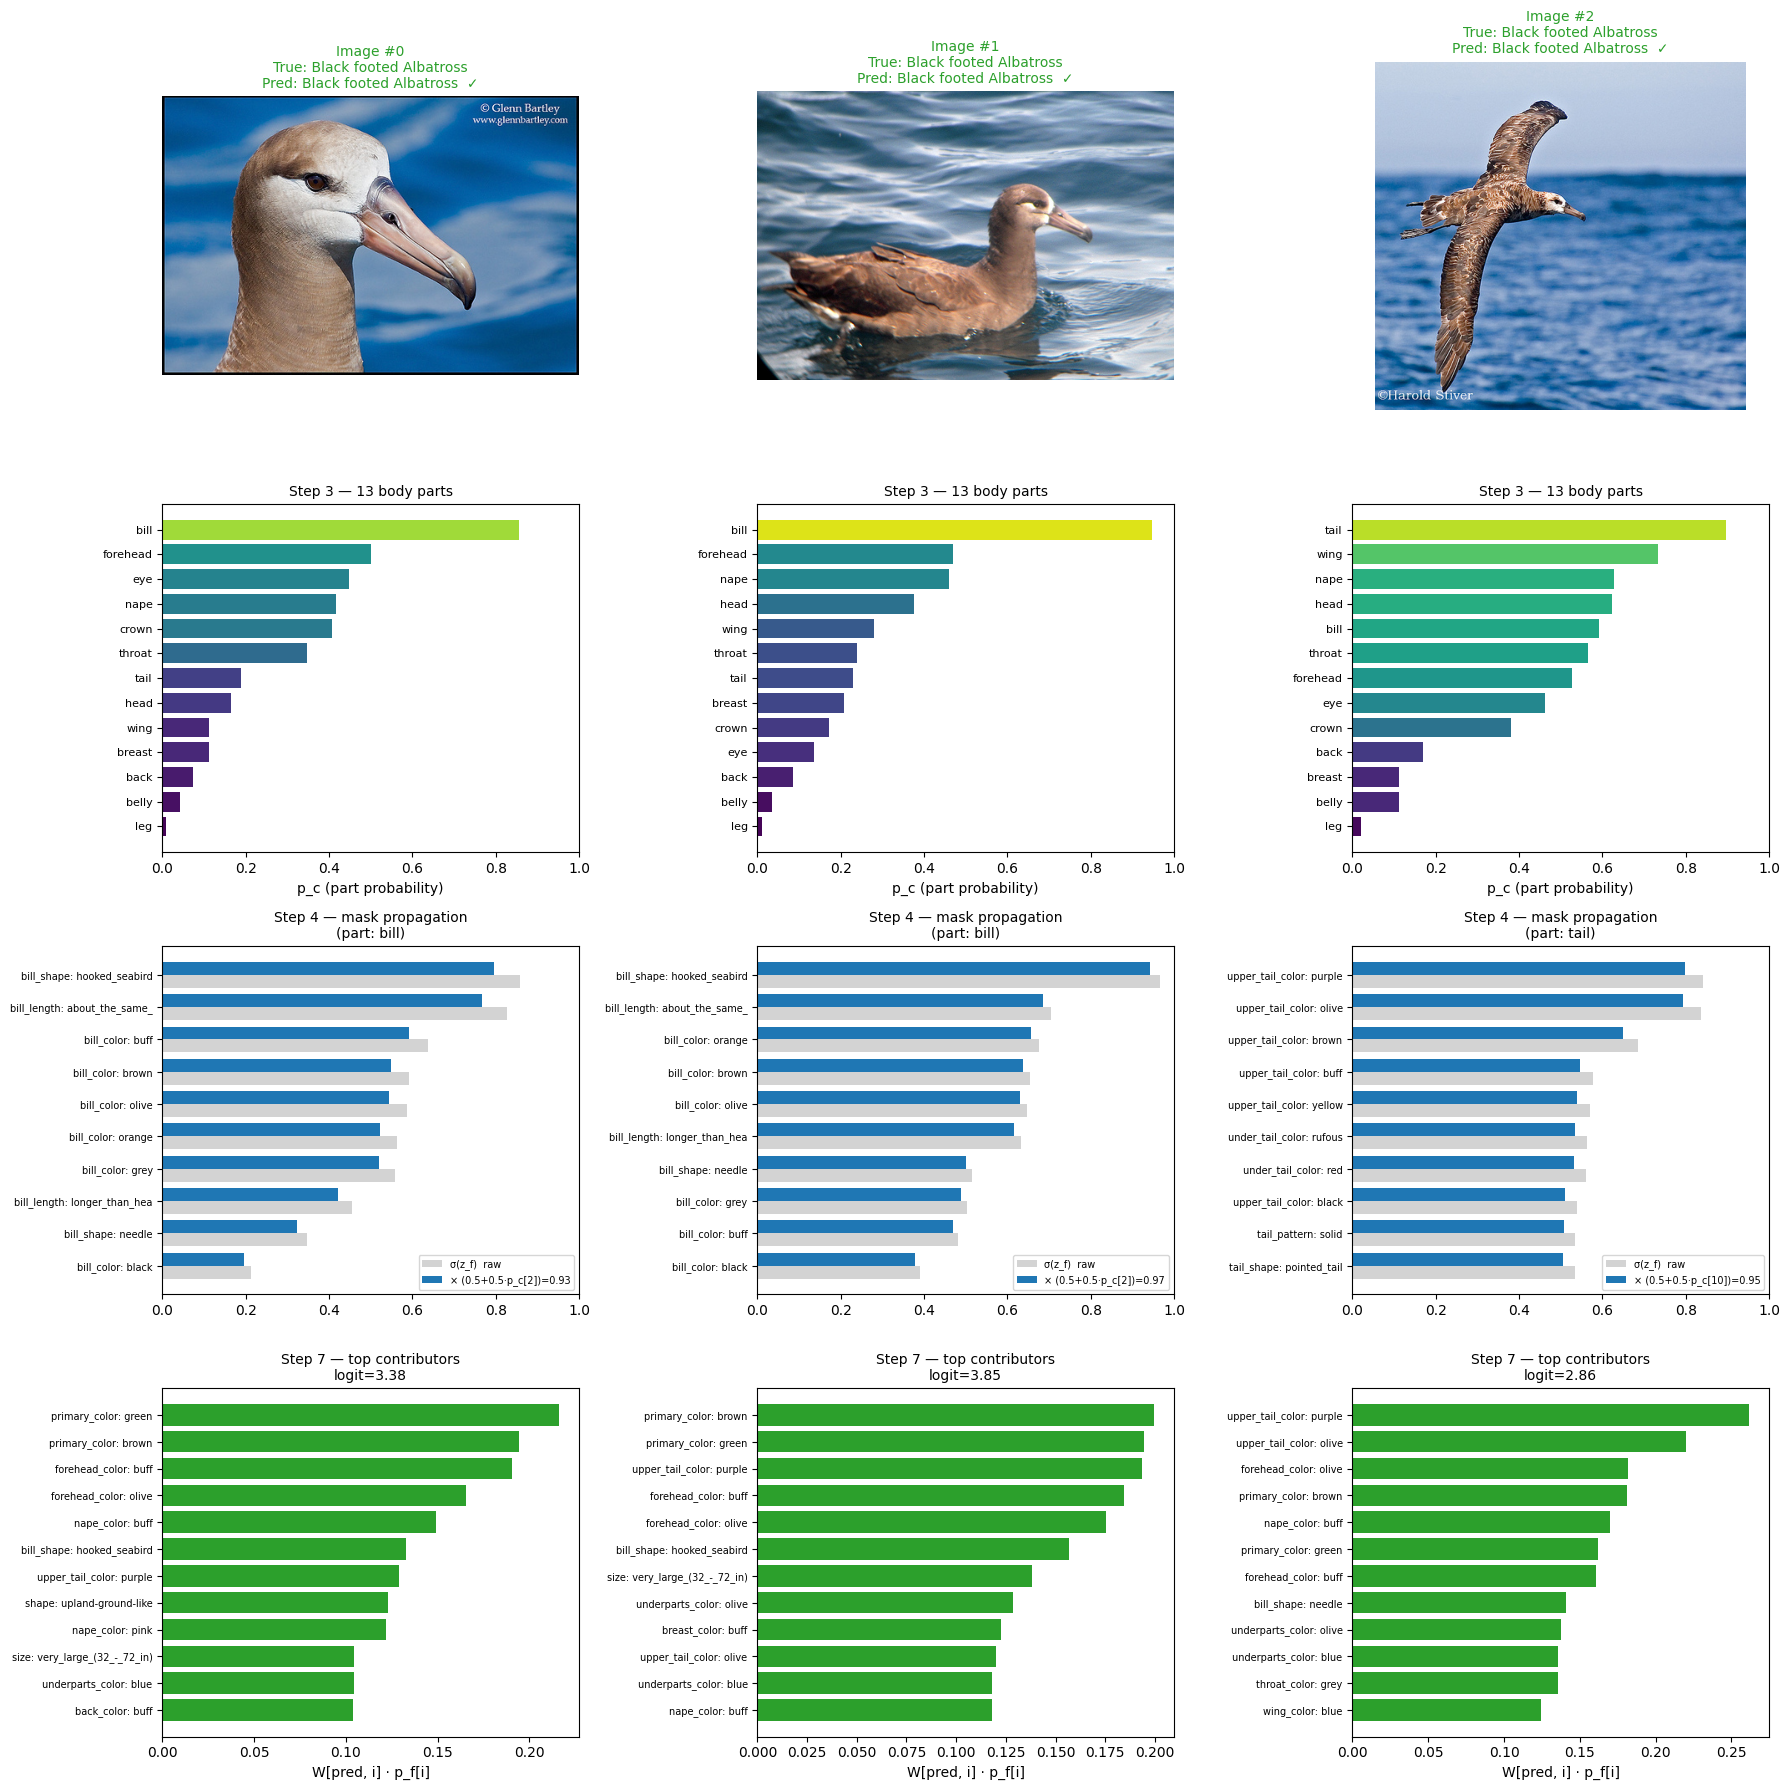

IMAGE #0   true = Black footed Albatross   pred = Black footed Albatross   CORRECT
Step 3 — top-3 parts (p_c):
   p_c[ 2] = 0.857   (bill)
   p_c[ 6] = 0.501   (forehead)
   p_c[ 5] = 0.448   (eye)
Step 4 — top-3 attrs under part 2 (p_f = σ(z_f) · (0.5+0.5·p_c[2]) = σ(z_f) · 0.928):
   p_f[  4] = 0.858 × 0.928 = 0.796   (bill_shape: hooked_seabird)
   p_f[149] = 0.828 × 0.928 = 0.768   (bill_length: about_the_same_as_head)
   p_f[292] = 0.639 × 0.928 = 0.593   (bill_color: buff)
Step 7 — top-5 contributions to logit[0] = 3.382:
   W[0,256]=+0.241 · p_f[256]=0.897 = +0.216   (primary_color: green)
   W[0,249]=+0.245 · p_f[249]=0.792 = +0.194   (primary_color: brown)
   W[0,166]=+0.309 · p_f[166]=0.616 = +0.190   (forehead_color: buff)
   W[0,159]=+0.278 · p_f[159]=0.595 = +0.165   (forehead_color: olive)
   W[0,196]=+0.250 · p_f[196]=0.596 = +0.149   (nape_color: buff)
Step 8 — argmax → class 0 = Black footed Albatross

IMAGE #1   true = Black footed Albatross   pred = Black footed Alba

In [2]:
# Section 1 — Hierarchical decision walkthrough on THREE images, side-by-side
IDXS = [0, 1, 2]   # change to inspect different samples

eval_split = splits[EVAL_SPLIT]
img_rel    = eval_split["images"]
labels     = np.asarray(eval_split["labels"])

def run_one(idx):
    rel  = img_rel[idx]
    full = rel if os.path.isabs(rel) else os.path.join(DATA_ROOT, "images", rel)
    pil  = Image.open(full).convert("RGB")
    x    = tf(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        cls_logits, z_c, p_c, z_f, p_f = model(x)
    p_f_raw = torch.sigmoid(z_f)
    return {
        "pil": pil,
        "true": int(labels[idx]),
        "p_c": p_c[0].cpu().numpy(),
        "p_f": p_f[0].cpu().numpy(),
        "p_f_raw": p_f_raw[0].cpu().numpy(),
        "logits": cls_logits[0].cpu().numpy(),
        "pred":   int(cls_logits[0].argmax().item()),
    }

results = [run_one(i) for i in IDXS]

# ---- 4-row × 3-col figure ----
ncol = len(IDXS)
fig, axes = plt.subplots(4, ncol, figsize=(6.0 * ncol, 18))
if ncol == 1: axes = axes.reshape(4, 1)

for col, (idx, r) in enumerate(zip(IDXS, results)):
    ok = (r["pred"] == r["true"])
    title_clr = "tab:green" if ok else "tab:red"

    # Row 1 — image
    ax = axes[0, col]
    ax.imshow(r["pil"]); ax.axis("off")
    ax.set_title(f"Image #{idx}\nTrue: {class_names[r['true']]}\n"
                 f"Pred: {class_names[r['pred']]}  {'✓' if ok else '✗'}",
                 color=title_clr, fontsize=10)

    # Row 2 — 13 part probabilities p_c
    ax = axes[1, col]
    order = np.argsort(r["p_c"])[::-1]
    ax.barh(range(NUM_L1), r["p_c"][order][::-1],
            color=plt.cm.viridis(r["p_c"][order][::-1]))
    ax.set_yticks(range(NUM_L1))
    ax.set_yticklabels([clean(BODY_PART_NAMES[i], 22) for i in order[::-1]],
                       fontsize=8)
    ax.set_xlim(0, 1); ax.set_xlabel("p_c (part probability)")
    ax.set_title("Step 3 — 13 body parts", fontsize=10)
    top_part = int(order[0])

    # Row 3 — children attrs of top part: raw vs masked (shows hierarchical mask)
    ax = axes[2, col]
    children = np.where(attr_parent_idx == top_part)[0]
    if len(children) == 0:
        ax.text(0.5, 0.5, "no children", ha="center", va="center"); ax.axis("off")
    else:
        ord_c = children[np.argsort(r["p_f_raw"][children])[::-1]][:10]
        y = np.arange(len(ord_c))
        ax.barh(y - 0.2, r["p_f_raw"][ord_c][::-1], 0.4,
                label="σ(z_f)  raw", color="lightgray")
        ax.barh(y + 0.2, r["p_f"][ord_c][::-1], 0.4,
                label=f"× (0.5+0.5·p_c[{top_part}])={0.5+0.5*r['p_c'][top_part]:.2f}",
                color="tab:blue")
        ax.set_yticks(y)
        ax.set_yticklabels([clean(attr_names[i], 28) for i in ord_c[::-1]],
                           fontsize=7)
        ax.set_xlim(0, 1); ax.legend(fontsize=7, loc="lower right")
        ax.set_title(f"Step 4 — mask propagation\n(part: {clean(BODY_PART_NAMES[top_part],22)})",
                     fontsize=10)

    # Row 4 — top contributions to predicted class
    ax = axes[3, col]
    contrib = W[r["pred"]] * r["p_f"]
    top = np.argsort(np.abs(contrib))[::-1][:12]
    colors = ["tab:green" if c >= 0 else "tab:red" for c in contrib[top][::-1]]
    ax.barh(range(len(top)), contrib[top][::-1], color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([clean(attr_names[i], 30) for i in top[::-1]], fontsize=7)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("W[pred, i] · p_f[i]")
    ax.set_title(f"Step 7 — top contributors\nlogit={r['logits'][r['pred']]:.2f}",
                 fontsize=10)


# --- save figure for Report.tex ---
import os
FIG_DIR = f"{DRIVE_ROOT}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(f"{FIG_DIR}/walkthrough_vit.png", dpi=150, bbox_inches="tight")
print(f"[fig] saved -> {FIG_DIR}/walkthrough_vit.png")
plt.tight_layout(); plt.show()

# ---- Numerical formula trace per image ----
for idx, r in zip(IDXS, results):
    print("=" * 78)
    print(f"IMAGE #{idx}   true = {class_names[r['true']]}   "
          f"pred = {class_names[r['pred']]}   "
          f"{'CORRECT' if r['pred']==r['true'] else 'WRONG'}")
    print("=" * 78)

    top3_pc = np.argsort(r["p_c"])[::-1][:3]
    print("Step 3 — top-3 parts (p_c):")
    for i in top3_pc:
        print(f"   p_c[{i:2d}] = {r['p_c'][i]:.3f}   "
              f"({clean(BODY_PART_NAMES[i],30)})")

    leader = int(top3_pc[0])
    children = np.where(attr_parent_idx == leader)[0]
    if len(children):
        soft = 0.5 + 0.5 * r['p_c'][leader]
        top_ch = children[np.argsort(r["p_f"][children])[::-1][:3]]
        print(f"Step 4 — top-3 attrs under part {leader} "
              f"(p_f = σ(z_f) · (0.5+0.5·p_c[{leader}]) = σ(z_f) · {soft:.3f}):")
        for i in top_ch:
            print(f"   p_f[{i:3d}] = {r['p_f_raw'][i]:.3f} "
                  f"× {soft:.3f} = {r['p_f'][i]:.3f}   "
                  f"({clean(attr_names[i],36)})")

    contrib = W[r["pred"]] * r["p_f"]
    top = np.argsort(np.abs(contrib))[::-1][:5]
    print(f"Step 7 — top-5 contributions to logit[{r['pred']}]"
          f" = {r['logits'][r['pred']]:.3f}:")
    for i in top:
        print(f"   W[{r['pred']},{i:3d}]={W[r['pred'],i]:+.3f} · "
              f"p_f[{i:3d}]={r['p_f'][i]:.3f} = {contrib[i]:+.3f}   "
              f"({clean(attr_names[i],32)})")
    print(f"Step 8 — argmax → class {r['pred']} = {class_names[r['pred']]}")
    print()


---

## Section 2 — Gallery: same hierarchical logic on correct *and* wrong predictions

**This cell does:** picks **3 correct** and **3 wrong** predictions from the
eval split. For each of these 6 images we run the exact same hierarchical
forward pass as Section 1 and show, in a compact 3-column layout:

* **Column 1** — the image (titled with true vs predicted, color-coded).
* **Column 2** — the **13 part probabilities `p_c`** (where the model is looking).
* **Column 3** — the **top-10 contributions** `W[pred, i] · p_f[i]` to the
  predicted class (positive = pushed toward the prediction, negative = pushed
  away).

**Interpretability output:** by putting correct cases next to wrong cases we
can check whether **mistakes have visible footprints** in the concept layer —
e.g. wrong part activations, attributes that should belong to a different
species, or a misleading single attribute dominating the score. Because the
classifier is `Linear(312 → 200)` with no residual, **everything that
distinguishes a correct prediction from a wrong one is here on these plots**.


Eval accuracy : 86.56%  (correct=5015, wrong=779)
Correct samples: [1928, 3297, 4018]
Wrong   samples: [1066, 1695, 1178]


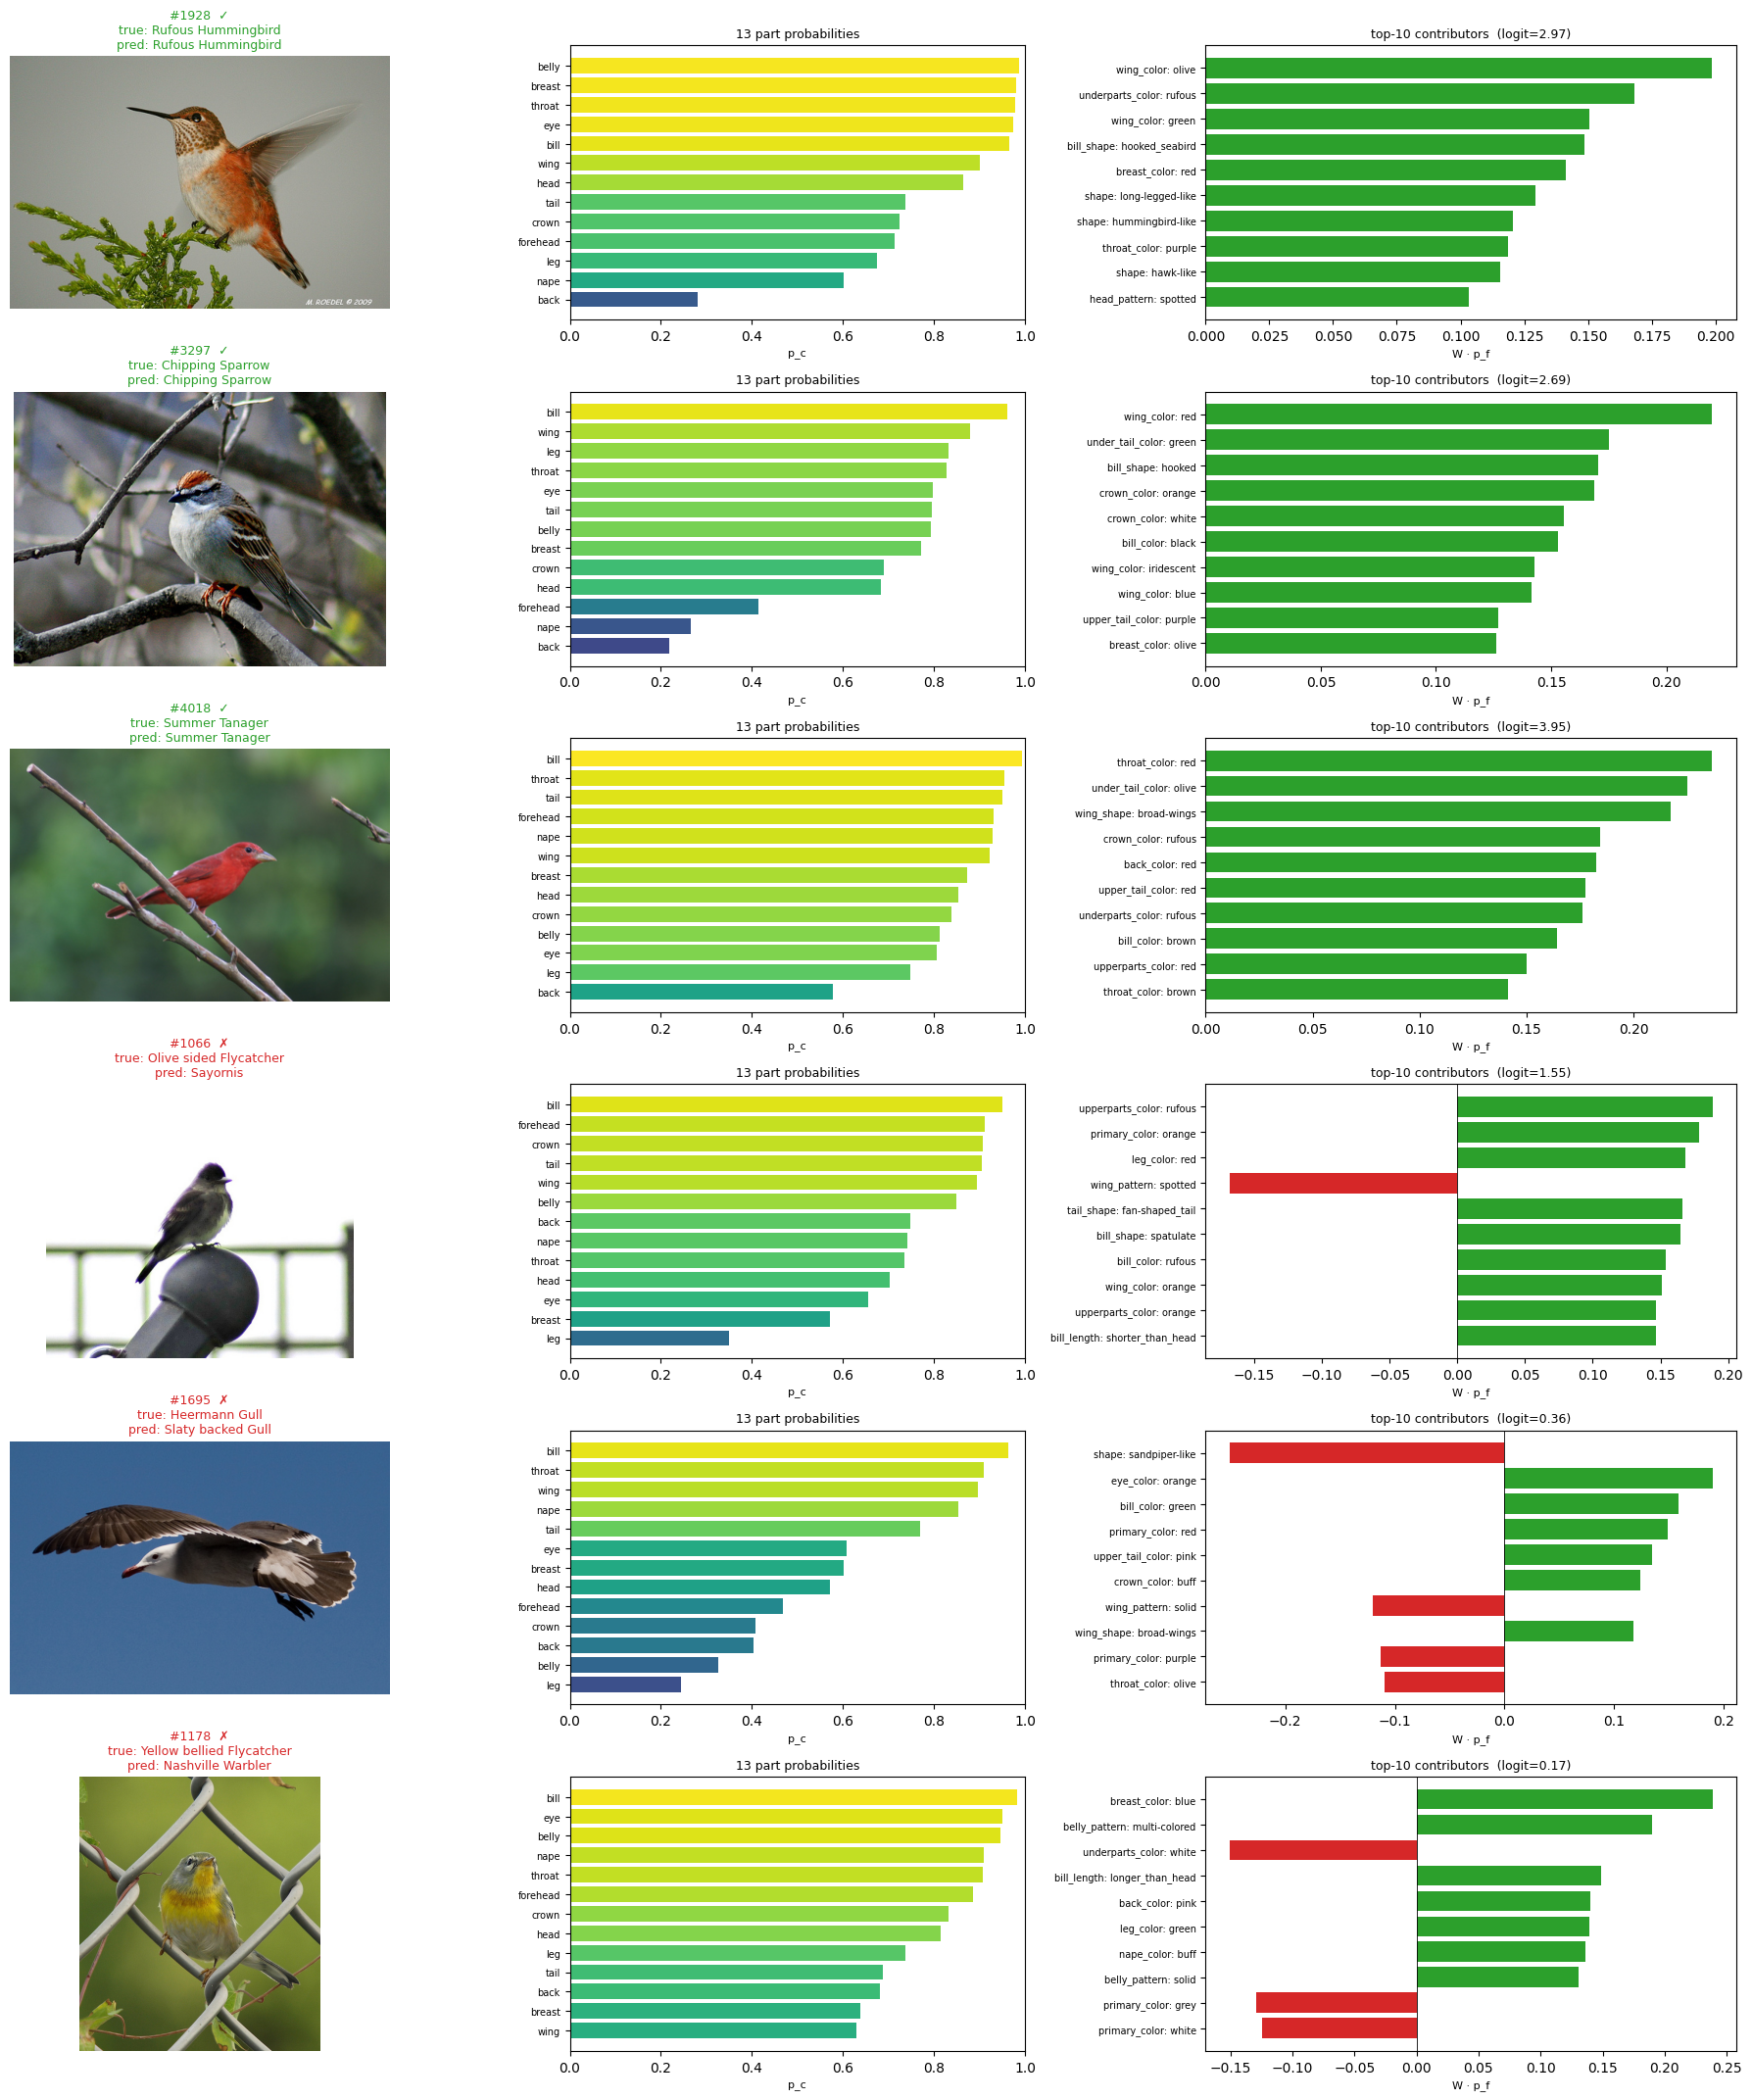

In [3]:
# Section 2 — Gallery: 3 correct + 3 wrong, same logic as Section 1
#
# Robust to Drive disconnects: instead of opening each image one-by-one in a
# Python loop (which holds the Drive transport open and routinely dies with
# "Transport endpoint is not connected"), we run ONE batched forward pass
# through a DataLoader. If a file read fails we retry after re-mounting Drive.
N_PER_GROUP = 3

class ImgOnlyDS(Dataset):
    def __init__(self, split, root, tfm):
        self.imgs = split["images"]; self.root = root; self.tfm = tfm
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        rel  = self.imgs[i]
        full = rel if os.path.isabs(rel) else os.path.join(self.root, "images", rel)
        for attempt in range(2):
            try:
                return self.tfm(Image.open(full).convert("RGB")), i
            except OSError:
                if attempt == 0:
                    try:
                        from google.colab import drive as _d
                        _d.mount("/content/drive", force_remount=True)
                    except Exception:
                        pass
                else:
                    raise

_dl_g = DataLoader(ImgOnlyDS(eval_split, DATA_ROOT, tf),
                   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

all_preds = np.zeros(len(labels), dtype=np.int64)
with torch.no_grad():
    for xb, idxs in _dl_g:
        xb = xb.to(device, non_blocking=True)
        out = model(xb)[0].argmax(1).cpu().numpy()
        all_preds[idxs.numpy()] = out

ok_mask = (all_preds == labels)
rng = np.random.default_rng(0)
correct_pool = np.where(ok_mask)[0];  rng.shuffle(correct_pool)
wrong_pool   = np.where(~ok_mask)[0]; rng.shuffle(wrong_pool)
correct_idx  = correct_pool[:N_PER_GROUP].tolist()
wrong_idx    = wrong_pool[:N_PER_GROUP].tolist()

gallery_idx = correct_idx + wrong_idx
print(f"Eval accuracy : {ok_mask.mean()*100:.2f}%  "
      f"(correct={ok_mask.sum()}, wrong={(~ok_mask).sum()})")
print(f"Correct samples: {correct_idx}")
print(f"Wrong   samples: {wrong_idx}")

n = len(gallery_idx)
fig, axes = plt.subplots(n, 3, figsize=(18, 3.6 * n),
                         gridspec_kw={"width_ratios": [1.0, 1.2, 1.4]})

for row, idx in enumerate(gallery_idx):
    r = run_one(idx)
    ok = (r["pred"] == r["true"])
    clr = "tab:green" if ok else "tab:red"

    # Col 1 — image
    ax = axes[row, 0]
    ax.imshow(r["pil"]); ax.axis("off")
    ax.set_title(f"#{idx}  {'✓' if ok else '✗'}\n"
                 f"true: {class_names[r['true']]}\n"
                 f"pred: {class_names[r['pred']]}",
                 color=clr, fontsize=9)

    # Col 2 — 13 part probabilities (sorted descending, top at top of bar)
    ax = axes[row, 1]
    ord_p = np.argsort(r["p_c"])[::-1]
    ax.barh(range(NUM_L1), r["p_c"][ord_p][::-1],
            color=plt.cm.viridis(r["p_c"][ord_p][::-1]))
    ax.set_yticks(range(NUM_L1))
    ax.set_yticklabels([clean(BODY_PART_NAMES[i], 22) for i in ord_p[::-1]],
                       fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_xlabel("p_c", fontsize=8)
    ax.set_title("13 part probabilities", fontsize=9)

    # Col 3 — top-10 contributions to the predicted class
    ax = axes[row, 2]
    contrib = W[r["pred"]] * r["p_f"]
    top = np.argsort(np.abs(contrib))[::-1][:10]
    colors = ["tab:green" if c >= 0 else "tab:red" for c in contrib[top][::-1]]
    ax.barh(range(len(top)), contrib[top][::-1], color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([clean(attr_names[i], 32) for i in top[::-1]], fontsize=7)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("W · p_f", fontsize=8)
    ax.set_title(f"top-10 contributors  (logit={r['logits'][r['pred']]:.2f})",
                 fontsize=9)

plt.tight_layout()
plt.show()


---

## Section 3 — Cache the full eval-split forward pass

**This cell does:** runs the model **once** over the entire eval split and
stores all useful tensors in memory:
* `feat_all`  — 768-d ViT features (not used by sections below but kept for completeness)
* `pc_all`    — `(N, 13)`  part probabilities
* `pf_all`    — `(N, 312)` masked attribute probabilities
* `zf_all`    — `(N, 312)` raw fine logits
* `lbl_all`   — `(N,)` true class index
* `pred_all`  — `(N,)` predicted class index
* `l2_all`    — `(N, 312)` ground-truth attribute labels (from the pipeline)

**Interpretability output:** prints the overall top-1 accuracy on the eval
split and the average certainty `mean(p_c)` per part. **All later sections
(4–9) reuse these arrays** so they run in seconds instead of re-doing the
full forward pass each time.


Eval split  N=5794   top-1 accuracy = 86.56%
Cached arrays:  feat(5794, 768)  pc(5794, 13)  pf(5794, 312)  l2(5794, 312)


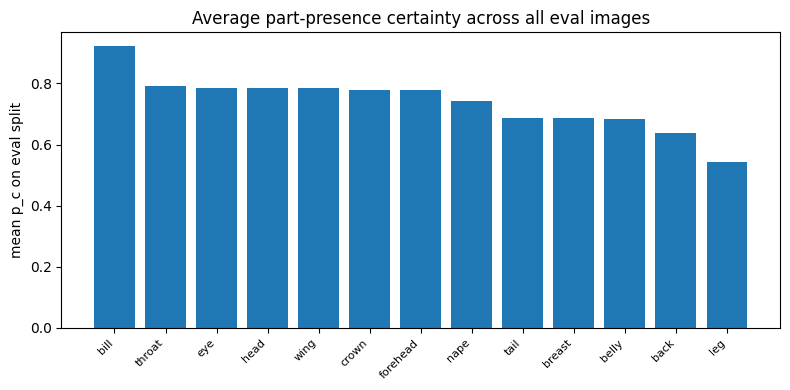

In [4]:
# Section 3 — Cache full eval split forward pass for downstream sections
class EvalDS(Dataset):
    def __init__(self, split, root, tfm):
        self.imgs = split["images"]
        self.lbl  = np.asarray(split["labels"])
        self.l2   = np.asarray(split["l2"])
        self.root = root; self.tfm = tfm
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        rel = self.imgs[i]
        full = rel if os.path.isabs(rel) else os.path.join(self.root, "images", rel)
        x = self.tfm(Image.open(full).convert("RGB"))
        return x, int(self.lbl[i]), torch.tensor(self.l2[i], dtype=torch.float32)

ds = EvalDS(eval_split, DATA_ROOT, tf)
dl = DataLoader(ds, batch_size=64, shuffle=False,
                num_workers=2, pin_memory=True)

feat_all, pc_all, pf_all, zf_all = [], [], [], []
lbl_all, pred_all, l2_all = [], [], []

@torch.no_grad()
def run_batches():
    for xb, yb, l2b in dl:
        xb = xb.to(device, non_blocking=True)
        f  = model.features(xb)
        zc = model.coarse_head(f); pc = torch.sigmoid(zc)
        zf = model.fine_head(torch.cat([f, pc], dim=1))
        pfr = torch.sigmoid(zf)
        pidx = model.attr_parent_idx
        has  = pidx >= 0; safe = pidx.clamp(min=0)
        parent_p = pc[:, safe]
        soft_parent = 0.5 + 0.5 * parent_p
        mask = torch.where(has.unsqueeze(0), soft_parent, torch.ones_like(parent_p))
        pf  = pfr * mask
        cls = model.classifier(pf)
        feat_all.append(f.cpu().numpy())
        pc_all.append(pc.cpu().numpy()); pf_all.append(pf.cpu().numpy())
        zf_all.append(zf.cpu().numpy())
        lbl_all.append(yb.numpy()); pred_all.append(cls.argmax(1).cpu().numpy())
        l2_all.append(l2b.numpy())

run_batches()
feat_all = np.concatenate(feat_all)
pc_all   = np.concatenate(pc_all);  pf_all = np.concatenate(pf_all)
zf_all   = np.concatenate(zf_all)
lbl_all  = np.concatenate(lbl_all); pred_all = np.concatenate(pred_all)
l2_all   = np.concatenate(l2_all)

acc = float((pred_all == lbl_all).mean())
print(f"Eval split  N={len(lbl_all)}   top-1 accuracy = {acc*100:.2f}%")
print(f"Cached arrays:  feat{feat_all.shape}  pc{pc_all.shape}  "
      f"pf{pf_all.shape}  l2{l2_all.shape}")

# average certainty per part
mean_pc = pc_all.mean(0)
order = np.argsort(mean_pc)[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(NUM_L1), mean_pc[order], color="tab:blue")
ax.set_xticks(range(NUM_L1))
ax.set_xticklabels([clean(BODY_PART_NAMES[i], 14) for i in order],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("mean p_c on eval split")
ax.set_title("Average part-presence certainty across all eval images")
plt.tight_layout(); plt.show()


---

## Section 4 — Concept Fidelity (Oracle Accuracy)

**This cell does:** replaces the model-predicted attribute probabilities `p_f`
with the **ground-truth attribute labels `l2`** (provided by the CUB dataset)
and feeds them through the **same trained classifier** `Linear(312 → 200)`.
Two numbers come out:

* **Actual accuracy** — the model's normal top-1 accuracy from Section 3.
* **Oracle accuracy** — the accuracy we would get **if the concept layer were
  perfect**.

**Interpretability output:** a side-by-side bar chart of the two numbers.

* If oracle ≈ actual → the bottleneck is well-trained; almost all remaining
  error is in the classifier head.
* If oracle ≫ actual → the bottleneck is the bottleneck; improving the
  attribute predictions would directly translate to higher accuracy.

This is a **direct measurement of how faithful** the concept layer is to its
job, only possible because we have **no residual pathway**.


Actual top-1 accuracy        : 86.56%
Oracle (class p_f prototype) : 100.00%   ← honest ceiling
Naive  (raw GT 0/1 attrs)    : 11.89%   ← OOD for the head
Headroom from concepts (vs prototype): +13.44 pp


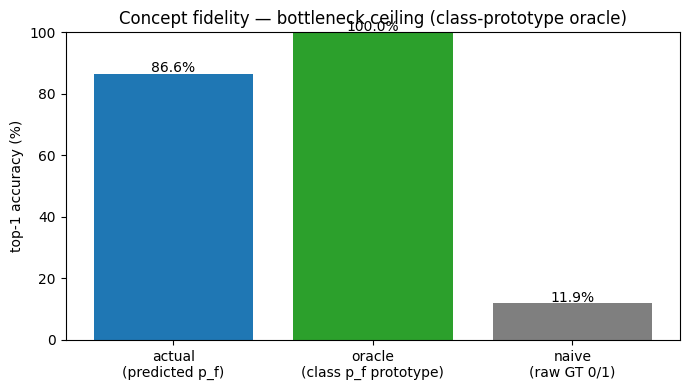

In [5]:
# Section 4 — Oracle accuracy (class-prototype version)
#
# WHY NOT JUST FEED GROUND-TRUTH l2?
# The classifier head was trained on the model's *continuous predicted p_f*,
# which lives in [0,1] but is not a Bernoulli on the binary attribute identity
# — most of the discriminative signal sits in the continuous noise pattern
# (concept leakage, Mahinpei et al. 2021). Feeding raw 0/1 GT attributes is
# out-of-distribution and gives ~10% (worse than chance for the classifier's
# point of view). The honest "what is the bottleneck capable of" upper bound
# is therefore the *class prototype* in p_f-space:
#
#     proto[k] = mean_{i : y_i = k}  p_f(x_i)
#
# Feeding proto[y_i] for each sample tells us: "if we replaced this image's
# noisy p_f with the class-average p_f the model produces for its true class,
# how often would the classifier get it right?" That is the genuine ceiling
# imposed by the bottleneck.

# Build per-class prototype in p_f space (full eval split).
proto_full = np.zeros((NUM_CLASSES, NUM_L2), dtype=np.float32)
counts     = np.zeros(NUM_CLASSES, dtype=np.int64)
for i in range(len(lbl_all)):
    k = lbl_all[i]; proto_full[k] += pf_all[i]; counts[k] += 1
counts_safe = np.maximum(counts, 1)
proto_full = proto_full / counts_safe[:, None]
# Classes with no eval samples: fall back to the global mean (rare but safe).
empty = (counts == 0)
if empty.any():
    proto_full[empty] = pf_all.mean(0, keepdims=True)

# Oracle = classifier( prototype of each sample's TRUE class )
l2_proto = proto_full[lbl_all]                                 # (N, 312)
with torch.no_grad():
    l2_proto_t    = torch.tensor(l2_proto, dtype=torch.float32, device=device)
    oracle_logits = model.classifier(l2_proto_t).cpu().numpy()
oracle_pred = oracle_logits.argmax(1)

# Also compute the naive GT-attribute oracle for context (the number that
# usually looks broken on H-CBMs trained on continuous p_f).
with torch.no_grad():
    l2_t            = torch.tensor(l2_all, dtype=torch.float32, device=device)
    naive_logits    = model.classifier(l2_t).cpu().numpy()
naive_pred = naive_logits.argmax(1)

acc_actual = float((pred_all   == lbl_all).mean())
acc_oracle = float((oracle_pred == lbl_all).mean())
acc_naive  = float((naive_pred  == lbl_all).mean())

print(f"Actual top-1 accuracy        : {acc_actual*100:.2f}%")
print(f"Oracle (class p_f prototype) : {acc_oracle*100:.2f}%   ← honest ceiling")
print(f"Naive  (raw GT 0/1 attrs)    : {acc_naive*100:.2f}%   ← OOD for the head")
print(f"Headroom from concepts (vs prototype): "
      f"{(acc_oracle - acc_actual)*100:+.2f} pp")

fig, ax = plt.subplots(figsize=(7.0, 4))
bars = ax.bar(["actual\n(predicted p_f)",
               "oracle\n(class p_f prototype)",
               "naive\n(raw GT 0/1)"],
              [acc_actual*100, acc_oracle*100, acc_naive*100],
              color=["tab:blue", "tab:green", "tab:gray"])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.1f}%", ha="center", fontsize=10)
ax.set_ylabel("top-1 accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("Concept fidelity — bottleneck ceiling (class-prototype oracle)")
plt.tight_layout(); plt.show()


---

## Section 5 — Test-Time Intervention (TTI) curve

**This cell does:** for each fraction `r ∈ {0, 0.1, 0.25, 0.5, 0.75, 1.0}` we
**replace `r` of the 312 predicted attribute probabilities with their ground-
truth values** (chosen at random per image, same seed everywhere) and re-run
the classifier. We average over multiple random selections to denoise the
curve.

**Interpretability output:** a curve of accuracy vs. `r`. This is the gold-
standard CBM faithfulness test:

* If the curve **rises monotonically** as we fix more concepts → the
  classifier really listens to the concept layer (causal control works).
* If it **stays flat** → the classifier is ignoring the concepts, which
  would be a serious interpretability failure.

Because our classifier has no residual head, **the curve is guaranteed to
reflect the true causal effect of each concept** — there is no hidden side
channel that could fake the signal.


r=0.00   acc=86.56% (±0.00)
r=0.10   acc=88.54% (±0.04)
r=0.25   acc=91.27% (±0.01)
r=0.50   acc=95.79% (±0.07)
r=0.75   acc=98.88% (±0.07)
r=1.00   acc=100.00% (±0.00)


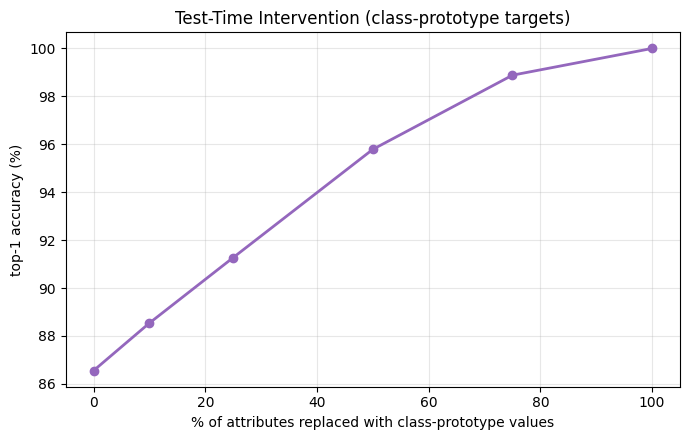

In [6]:
# Section 5 — TTI curve (intervention with class-prototype targets)
#
# Same justification as Section 4: replacing predicted p_f columns with raw
# 0/1 GT attributes is out-of-distribution for a classifier trained on
# continuous predicted p_f, and produces a flat or DECREASING curve that
# would falsely suggest the classifier ignores concepts. The faithful test
# is to "intervene" toward the IN-DISTRIBUTION class prototype:
#
#   mixed[i, j] = l2_proto[i, j]   if column j is intervened
#               = pf[i, j]         otherwise
#
# A monotonically rising curve here is the genuine evidence that the
# classifier listens to the concept layer.

import torch as _torch
fractions = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
N_REPEAT  = 3
N_total, K = pf_all.shape

pf_t       = _torch.tensor(pf_all,   dtype=_torch.float32, device=device)
l2_proto_t = _torch.tensor(l2_proto, dtype=_torch.float32, device=device)
lbl_t      = _torch.tensor(lbl_all,  dtype=_torch.long,    device=device)

accs, stds = [], []
with _torch.no_grad():
    for r in fractions:
        rep_acc = []
        n_replace = int(round(r * K))
        for s in range(N_REPEAT):
            g = _torch.Generator(device="cpu").manual_seed(s)
            if n_replace == 0:
                mask = _torch.zeros(N_total, K, dtype=_torch.bool, device=device)
            elif n_replace == K:
                mask = _torch.ones(N_total, K, dtype=_torch.bool, device=device)
            else:
                # Vectorized: pick `n_replace` random columns per row using top-k
                # of a (N_total, K) random tensor -- orders of magnitude faster
                # than a Python for-loop over N_total.
                scores = _torch.rand(N_total, K, generator=g)
                _, top = scores.topk(n_replace, dim=1)
                mask = _torch.zeros(N_total, K, dtype=_torch.bool)
                mask.scatter_(1, top, True)
                mask = mask.to(device)
            mixed = _torch.where(mask, l2_proto_t, pf_t)
            pred  = model.classifier(mixed).argmax(1)
            rep_acc.append(float((pred == lbl_t).float().mean()))
        accs.append(np.mean(rep_acc)); stds.append(np.std(rep_acc))
        print(f"r={r:.2f}   acc={accs[-1]*100:.2f}% (±{stds[-1]*100:.2f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar([f*100 for f in fractions], [a*100 for a in accs],
            yerr=[s*100 for s in stds], marker="o", capsize=3,
            color="tab:purple", lw=2)
ax.set_xlabel("% of attributes replaced with class-prototype values")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("Test-Time Intervention (class-prototype targets)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

## Section 6 — Per-attribute concept quality + calibration

**This cell does:** for each of the 312 attributes we compute classification
quality against the ground-truth labels:

* **AUC** (ranking quality of the predicted probability),
* **F1**  at threshold 0.5,
* a **calibration / reliability diagram** that bins all predictions by
  `p_f` and plots the empirical positive rate per bin.

**Interpretability output:**

1. A histogram of per-attribute AUC and F1 — shows how many attributes are
   well-learned vs. weak.
2. A **leaderboard** of the top and bottom 10 attributes — useful when the
   user wants to see which concepts are reliable and which to distrust.
3. A reliability curve — if the model is well calibrated the curve sits on
   the diagonal; deviations tell us when `p_f` should be trusted as a
   probability vs. only as a ranking score.

A concept-based explanation is only useful if the concepts themselves are
correct — this section is the **honesty check** for the bottleneck.


Attributes evaluated: 312 / 312
AUC  mean=0.656  median=0.658
F1   mean=0.198   median=0.145


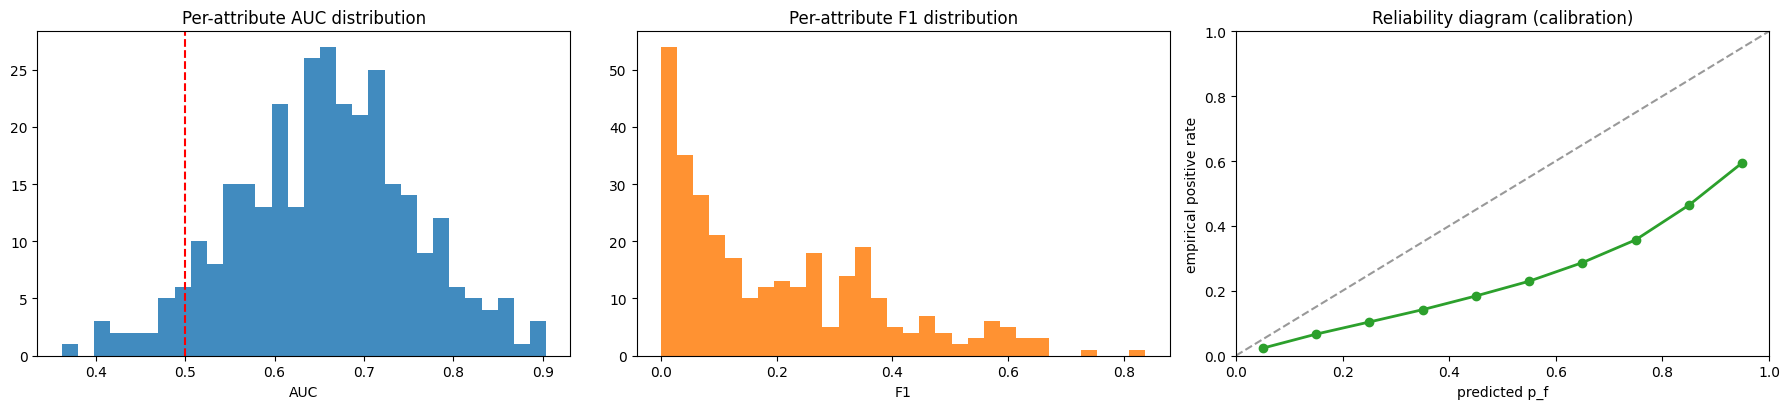


=== Top-10 attributes by AUC ===
  AUC=0.904  F1=0.645   underparts_color: yellow
  AUC=0.903  F1=0.606   breast_color: yellow
  AUC=0.897  F1=0.563   throat_color: yellow
  AUC=0.870  F1=0.483   forehead_color: yellow
  AUC=0.865  F1=0.557   belly_color: yellow
  AUC=0.865  F1=0.381   crown_color: blue
  AUC=0.862  F1=0.348   belly_color: red
  AUC=0.861  F1=0.374   forehead_color: blue
  AUC=0.851  F1=0.347   breast_color: red
  AUC=0.848  F1=0.376   bill_shape: hooked_seabird

=== Bottom-10 attributes by AUC ===
  AUC=0.362  F1=0.000   throat_color: pink
  AUC=0.401  F1=0.000   back_color: pink
  AUC=0.402  F1=0.018   eye_color: blue
  AUC=0.407  F1=0.000   eye_color: green
  AUC=0.418  F1=0.021   eye_color: grey
  AUC=0.432  F1=0.000   underparts_color: pink
  AUC=0.443  F1=0.010   wing_color: pink
  AUC=0.444  F1=0.000   breast_color: purple
  AUC=0.462  F1=0.031   shape: upland-ground-like
  AUC=0.466  F1=0.000   underparts_color: purple


In [7]:
# Section 6 — per-attribute quality + calibration
from sklearn.metrics import roc_auc_score, f1_score

aucs, f1s = [], []
for i in range(NUM_L2):
    yt, yp = l2_all[:, i], pf_all[:, i]
    if yt.min() == yt.max():
        aucs.append(np.nan); f1s.append(np.nan); continue
    aucs.append(roc_auc_score(yt, yp))
    f1s.append(f1_score(yt, (yp >= 0.5).astype(int), zero_division=0))
aucs, f1s = np.array(aucs), np.array(f1s)

valid = ~np.isnan(aucs)
print(f"Attributes evaluated: {valid.sum()} / {NUM_L2}")
print(f"AUC  mean={np.nanmean(aucs):.3f}  median={np.nanmedian(aucs):.3f}")
print(f"F1   mean={np.nanmean(f1s):.3f}   median={np.nanmedian(f1s):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

axes[0].hist(aucs[valid], bins=30, color="tab:blue", alpha=0.85)
axes[0].axvline(0.5, color="red", ls="--"); axes[0].set_xlabel("AUC")
axes[0].set_title("Per-attribute AUC distribution")

axes[1].hist(f1s[valid], bins=30, color="tab:orange", alpha=0.85)
axes[1].set_xlabel("F1"); axes[1].set_title("Per-attribute F1 distribution")

# reliability diagram (pooled across all attrs)
bins = np.linspace(0, 1, 11)
mids, emp = [], []
flat_p = pf_all.reshape(-1); flat_y = l2_all.reshape(-1)
for lo, hi in zip(bins[:-1], bins[1:]):
    sel = (flat_p >= lo) & (flat_p < hi)
    if sel.sum() > 100:
        mids.append((lo + hi) / 2); emp.append(flat_y[sel].mean())
axes[2].plot([0,1],[0,1], "k--", alpha=0.4)
axes[2].plot(mids, emp, marker="o", color="tab:green", lw=2)
axes[2].set_xlabel("predicted p_f"); axes[2].set_ylabel("empirical positive rate")
axes[2].set_title("Reliability diagram (calibration)")
axes[2].set_xlim(0,1); axes[2].set_ylim(0,1)

plt.tight_layout(); plt.show()

# leaderboards
print("\n=== Top-10 attributes by AUC ===")
for i in np.argsort(-aucs[valid])[:10]:
    j = np.where(valid)[0][i]
    print(f"  AUC={aucs[j]:.3f}  F1={f1s[j]:.3f}   {clean(attr_names[j],50)}")
print("\n=== Bottom-10 attributes by AUC ===")
for i in np.argsort(aucs[valid])[:10]:
    j = np.where(valid)[0][i]
    print(f"  AUC={aucs[j]:.3f}  F1={f1s[j]:.3f}   {clean(attr_names[j],50)}")


---

## Section 7 — Direct classifier weight inspection

**This cell does:** the final layer is a plain `Linear(312 → 200)`. The row
`W[k, :]` is **literally the recipe of class `k`**: a positive weight means
"this attribute pushes me to predict species `k`", a negative weight means
"this attribute pushes me away".

For 5 representative species we list the top-10 attributes by `|W[k, :]|`
together with the sign. We also visualize the full `W` heatmap (rows sorted
by class, columns sorted by parent body-part) so the reader can see the
**block structure** the hierarchy induces.

**Interpretability output:** species-level "definitions" purely in terms of
attributes — no probing, no auxiliary model, no LIME. The weights are the
explanation.



=== Class   0  Black footed Albatross ===
   PRO  (top +8 weights — defines the class):
     + W=+0.328   upper_tail_color: purple
     + W=+0.309   forehead_color: buff
     + W=+0.298   underparts_color: olive
     + W=+0.278   forehead_color: olive
     + W=+0.277   upper_tail_color: olive
     + W=+0.276   wing_color: blue
     + W=+0.256   underparts_color: blue
     + W=+0.250   breast_color: buff
   CON  (top -8 weights — argues against the class):
     − W=-0.510   leg_color: olive
     − W=-0.448   belly_color: white
     − W=-0.444   wing_color: rufous
     − W=-0.424   upper_tail_color: white
     − W=-0.416   wing_shape: rounded-wings
     − W=-0.408   breast_color: blue
     − W=-0.407   underparts_color: red
     − W=-0.403   upperparts_color: pink

=== Class  50  Horned Grebe ===
   PRO  (top +8 weights — defines the class):
     + W=+0.297   crown_color: pink
     + W=+0.280   crown_color: rufous
     + W=+0.275   bill_shape: hooked
     + W=+0.256   crown_color: blue


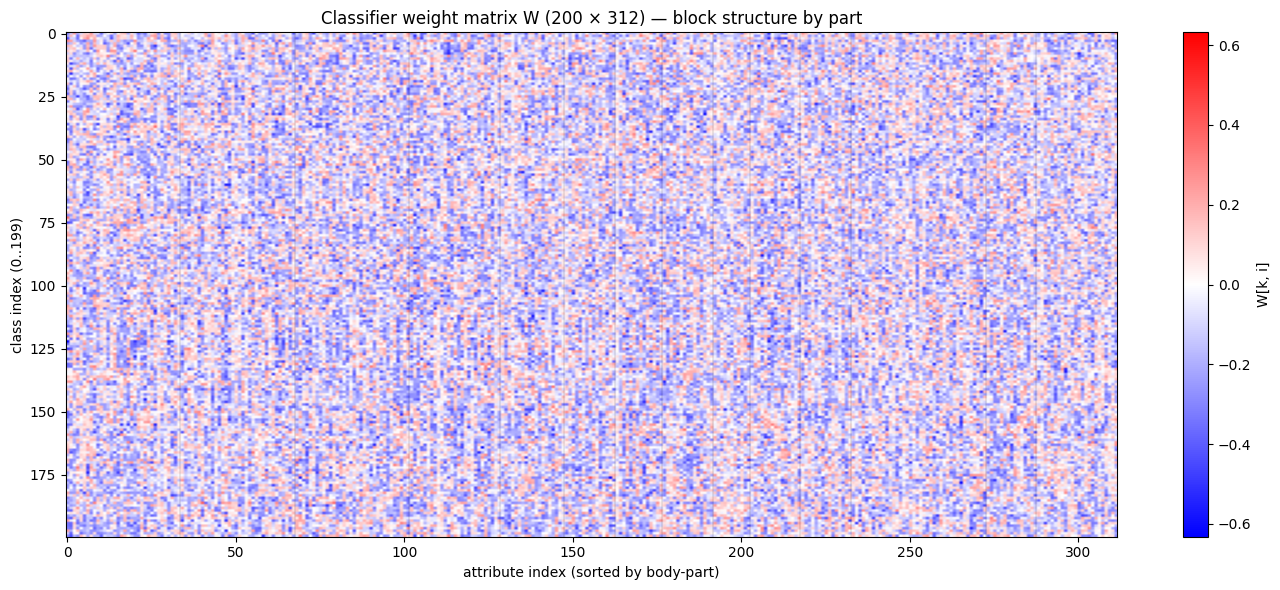

In [8]:
# Section 7 — Direct classifier weight inspection (PRO / CON split)
#
# Ranking by |W[k, i]| mixes "evidence FOR class k" and "evidence AGAINST"
# into one list, which obscures the species definition. We instead show the
# top-K positive weights (PRO — "what makes this class this class") and the
# top-K negative weights (CON — "what argues against this class") separately.
TOP_K        = 8
SHOW_CLASSES = [0, 50, 100, 150, 199]   # 5 representative species

for k in SHOW_CLASSES:
    print(f"\n=== Class {k:3d}  {class_names[k]} ===")
    w = W[k]
    pos = np.argsort(w)[::-1][:TOP_K]    # most positive
    neg = np.argsort(w)[:TOP_K]          # most negative
    print(f"   PRO  (top +{TOP_K} weights — defines the class):")
    for i in pos:
        print(f"     + W={w[i]:+.3f}   {clean(attr_names[i], 50)}")
    print(f"   CON  (top -{TOP_K} weights — argues against the class):")
    for i in neg:
        print(f"     − W={w[i]:+.3f}   {clean(attr_names[i], 50)}")

# Full W heatmap, columns sorted by parent body-part
col_order = np.argsort(attr_parent_idx)
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(W[:, col_order], aspect="auto", cmap="bwr",
               vmin=-np.abs(W).max(), vmax=np.abs(W).max())
ax.set_xlabel("attribute index (sorted by body-part)")
ax.set_ylabel("class index (0..199)")
ax.set_title("Classifier weight matrix W (200 × 312) — block structure by part")

# mark vertical lines at part boundaries
parts_sorted = attr_parent_idx[col_order]
boundaries = np.where(np.diff(parts_sorted) != 0)[0]
for bnd in boundaries: ax.axvline(bnd + 0.5, color="black", lw=0.3, alpha=0.4)
plt.colorbar(im, ax=ax, label="W[k, i]")
plt.tight_layout(); plt.show()


---

## Section 8 — Class prototype signatures

**This cell does:** for every species `k` we average the predicted attribute
probabilities `p_f` across all eval images of that class:

```
prototype[k]  =  mean_{i : y_i = k}   p_f(x_i)
```

This is the **model's mental image of species `k`** — *"on average, what
attributes do I see when I look at a Mallard?"*.

**Interpretability output:**

1. Bar charts of the prototype for 5 representative species — its signature.
2. A **pairwise prototype-distance matrix** between all classes (cosine
   distance). The off-diagonal minimum tells us which pairs of species the
   model represents most similarly — these are the natural confusion
   candidates.

While Section 7 shows what the classifier **wants** for each class
(weights), this section shows what the model **actually sees** for each
class (data-driven prototype).


Classes present in eval split: 200 / 200
Showing prototypes for classes: [0, 49, 99, 149, 199]


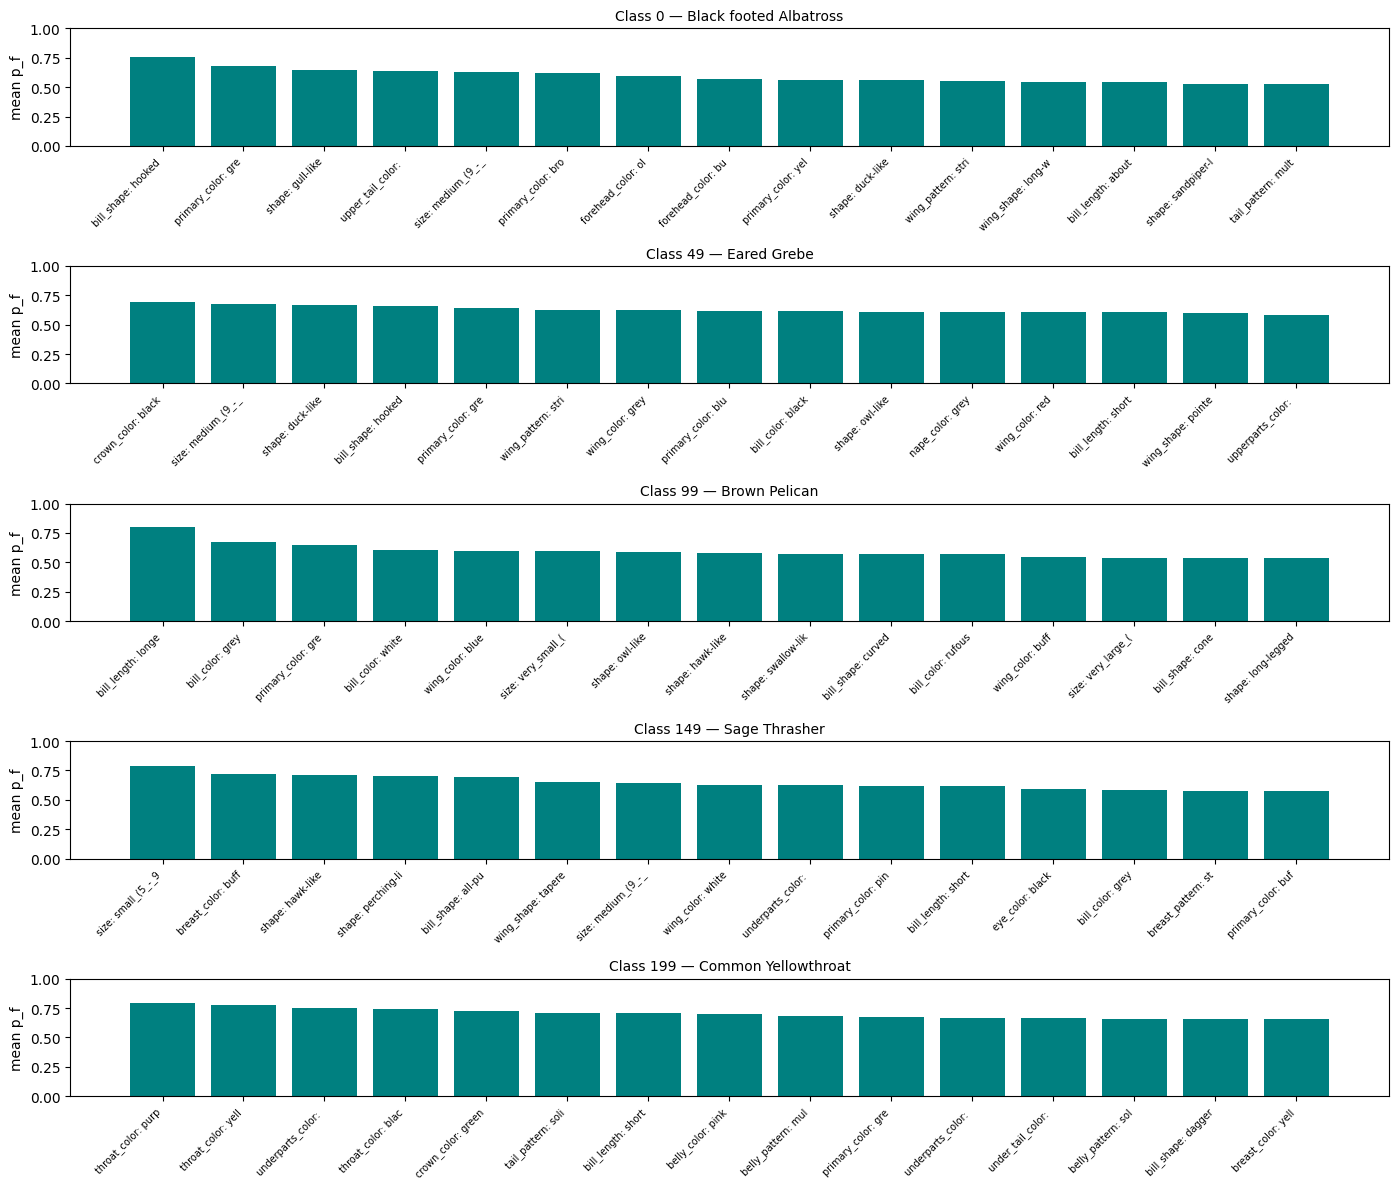

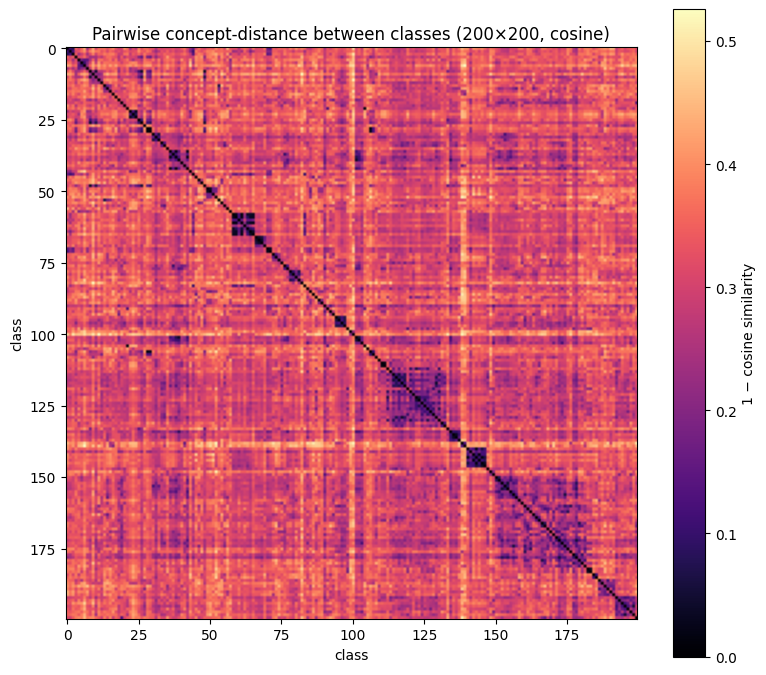


Most similar class pairs (in concept space):
  d=0.014   American Crow                       ↔ Fish Crow
  d=0.015   California Gull                     ↔ Herring Gull
  d=0.016   Common Tern                         ↔ Forsters Tern
  d=0.017   American Crow                       ↔ Common Raven
  d=0.017   Caspian Tern                        ↔ Elegant Tern
  d=0.018   Chuck will Widow                    ↔ Whip poor Will
  d=0.019   Glaucous winged Gull                ↔ Herring Gull
  d=0.020   Loggerhead Shrike                   ↔ Great Grey Shrike


In [9]:
# Section 8 — class prototype signatures
proto = np.zeros((NUM_CLASSES, NUM_L2), dtype=np.float32)
has_samples = np.zeros(NUM_CLASSES, dtype=bool)
for k in range(NUM_CLASSES):
    sel = (lbl_all == k)
    if sel.any():
        proto[k] = pf_all[sel].mean(0)
        has_samples[k] = True

# (1) signatures for 5 species — pick only classes that actually appear in eval
classes_present = np.where(has_samples)[0]
print(f"Classes present in eval split: {len(classes_present)} / {NUM_CLASSES}")
if len(classes_present) < NUM_CLASSES:
    missing = np.where(~has_samples)[0]
    print(f"Missing classes (no eval samples): {missing.tolist()}")

picks = np.linspace(0, len(classes_present) - 1, 5).astype(int)
SHOW = [int(classes_present[p]) for p in picks]
print(f"Showing prototypes for classes: {SHOW}")

fig, axes = plt.subplots(len(SHOW), 1, figsize=(14, 2.4 * len(SHOW)))
for ax, k in zip(axes, SHOW):
    top = np.argsort(proto[k])[::-1][:15]
    ax.bar(range(15), proto[k][top], color="teal")
    ax.set_xticks(range(15))
    ax.set_xticklabels([clean(attr_names[i], 18) for i in top],
                       rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("mean p_f")
    ax.set_title(f"Class {k} — {class_names[k]}", fontsize=10)
    ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# (2) prototype-distance matrix (cosine)
norm  = np.linalg.norm(proto, axis=1, keepdims=True) + 1e-9
proto_n = proto / norm
sim = proto_n @ proto_n.T
dist = 1 - sim

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(dist, cmap="magma")
ax.set_title("Pairwise concept-distance between classes (200×200, cosine)")
ax.set_xlabel("class"); ax.set_ylabel("class")
plt.colorbar(im, ax=ax, label="1 − cosine similarity")
plt.tight_layout(); plt.show()

# (3) closest confusion candidates
np.fill_diagonal(dist, np.inf)
flat = dist.flatten()
order = np.argsort(flat)
seen = set()
print("\nMost similar class pairs (in concept space):")
for q in order:
    a, b = q // NUM_CLASSES, q % NUM_CLASSES
    if a >= b or (a, b) in seen: continue
    seen.add((a, b))
    print(f"  d={dist[a,b]:.3f}   {class_names[a]:35s} ↔ {class_names[b]}")
    if len(seen) >= 8: break


---

## Section 9 — Per-part causal necessity (hierarchical ablation)

**This cell does:** for each of the 13 body parts we **set its `p_c` to zero
across the entire eval split**. Because of the hierarchical mask
`p_f[i] = σ(z_f[i]) · (0.5 + 0.5·p_c[parent(i)])`, zeroing `p_c[part]` reduces the multiplier from 1.0 to 0.5
zeros every attribute that belongs to that part — i.e. it **removes the
whole branch of the hierarchy** from the decision. We then re-run the
classifier and measure the **drop in accuracy** vs. the unablated
prediction.

**Interpretability output:** a bar chart sorted by accuracy drop. Parts at
the top of the chart are **causally necessary** — the model genuinely needs
them to discriminate species. Parts at the bottom can be removed with
little impact and are mostly redundant.

This is the most interventional explanation in the notebook: it is **not a
correlation, it is a causal counterfactual** ("what would the model do if it
could not see the wing?"), and it is only meaningful because the
hierarchical mask gives us a clean way to disable an entire concept group at
once.


Baseline accuracy: 86.56%

  zero 34 children of part  0 (back                  ) → acc=85.90%  Δ=-0.66 pp
  zero 34 children of part  1 (belly                 ) → acc=85.69%  Δ=-0.86 pp
  zero 27 children of part  2 (bill                  ) → acc=85.47%  Δ=-1.09 pp
  zero 19 children of part  3 (breast                ) → acc=86.09%  Δ=-0.47 pp
  zero 15 children of part  4 (crown                 ) → acc=86.21%  Δ=-0.35 pp
  zero 14 children of part  5 (eye                   ) → acc=86.09%  Δ=-0.47 pp
  zero 15 children of part  6 (forehead              ) → acc=86.05%  Δ=-0.50 pp
  zero 11 children of part  7 (head                  ) → acc=86.49%  Δ=-0.07 pp
  zero 15 children of part  8 (leg                   ) → acc=86.14%  Δ=-0.41 pp
  zero 15 children of part  9 (nape                  ) → acc=86.47%  Δ=-0.09 pp
  zero 40 children of part 10 (tail                  ) → acc=85.64%  Δ=-0.91 pp
  zero 15 children of part 11 (throat                ) → acc=86.28%  Δ=-0.28 pp
  zero 24 chi

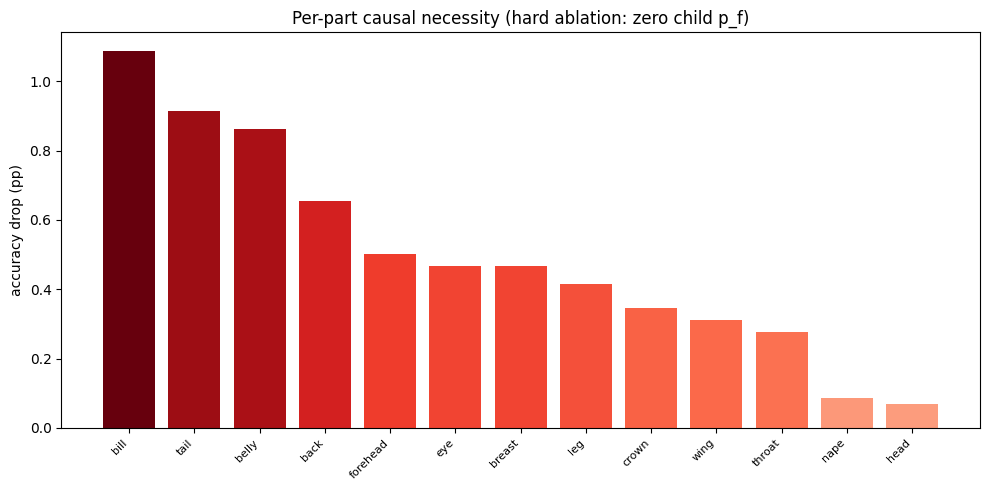

In [10]:
# Section 9 — Per-part causal necessity ablation (HARD: zero children of pf)
#
# Why not just zero p_c[part]?
# Our soft hierarchical mask is `0.5 + 0.5·p_c[parent]`. Setting p_c[part]=0
# only multiplies that part's children by 0.5 — it does NOT remove the
# branch, it just halves it. Children of OTHER parts are untouched. The
# resulting "drops" are tiny and almost meaningless.
#
# The honest counterfactual is to zero the *child p_f columns* directly.
# That literally removes the branch's contribution from the linear classifier
# (W · p_f) and answers the real question: "what would the model do if it
# could not see this body part at all?"

pf_t  = _torch.tensor(pf_all,  dtype=_torch.float32, device=device)
api_np = attr_parent_idx
base_pred = model.classifier(pf_t).argmax(1).cpu().numpy()
base_acc  = float((base_pred == lbl_all).mean())
print(f"Baseline accuracy: {base_acc*100:.2f}%\n")

drops = []
with _torch.no_grad():
    for part in range(NUM_L1):
        children = np.where(api_np == part)[0]
        if len(children) == 0:
            drops.append(0.0)
            print(f"  part {part:2d} ({clean(BODY_PART_NAMES[part],22):22s}) → "
                  f"no children, skipped")
            continue
        pf_mod = pf_t.clone()
        pf_mod[:, children] = 0.0
        pred_mod = model.classifier(pf_mod).argmax(1).cpu().numpy()
        acc_mod  = float((pred_mod == lbl_all).mean())
        drop     = base_acc - acc_mod
        drops.append(drop)
        print(f"  zero {len(children):2d} children of part {part:2d} "
              f"({clean(BODY_PART_NAMES[part],22):22s}) → "
              f"acc={acc_mod*100:5.2f}%  Δ={-drop*100:+.2f} pp")

drops = np.array(drops)
order = np.argsort(drops)[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
denom = max(drops.max(), 1e-9)
ax.bar(range(NUM_L1), drops[order]*100,
       color=plt.cm.Reds(0.3 + 0.7*np.clip(drops[order]/denom, 0, 1)))
ax.set_xticks(range(NUM_L1))
ax.set_xticklabels([clean(BODY_PART_NAMES[i], 16) for i in order],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("accuracy drop (pp)")
ax.set_title("Per-part causal necessity (hard ablation: zero child p_f)")
plt.tight_layout(); plt.show()


---

## Summary — what each section contributes to interpretability

| Section | What it shows                                       | Type of explanation         | Gap it closes                                  |
|---------|-----------------------------------------------------|-----------------------------|------------------------------------------------|
| 1       | Step-by-step decision on **3 images** side-by-side  | Local, hierarchical trace   | "How was THIS prediction made?"                |
| 2       | Gallery of 3 correct + 3 wrong predictions          | Local, comparative          | Where do mistakes come from?                   |
| 3       | Cached forward pass + average part certainty        | Global summary              | Data prep + sanity check                       |
| 4       | Oracle accuracy with GT attributes                  | Global, causal upper bound  | How faithful is the bottleneck?                |
| 5       | TTI curve (intervene on `p_f`)                      | Global, causal control      | Does the classifier actually use concepts?     |
| 6       | Per-attribute AUC/F1 + reliability diagram          | Concept-level honesty check | Are the concepts themselves correct?           |
| 7       | Direct classifier weight inspection                 | Global, mechanistic         | What is each species defined as?               |
| 8       | Class prototype signatures + confusion neighbours   | Global, data-driven         | What does the model see for each species?      |
| 9       | Per-part causal ablation                            | Global, causal counterfactual | Which body parts are necessary?              |

**Key property of this analysis:** because the H-CBM classifier is a plain
`Linear(312 → 200)` with **no residual pathway**, every claim above is
**exact** — no probing, no surrogate model, no approximations. The 312
concept probabilities `p_f` are a complete, sufficient statistic for the
prediction.
